# Connectivity Constraint via Morse Theory

This notebook explores using Morse theory to enforce connectivity in implicit neural shapes.

**Key Idea**: For a signed distance function f(x), the topology of the level set {f=0} is determined by critical points where ∇f = 0.

- **Minima** (index 0): Create new components
- **Saddle points** (index 1): Connect/disconnect components  
- **Maxima** (index 2 in 2D, index 3 in 3D): Create holes/voids

**Goal**: Find saddle points and penalize those with f(x) ≠ 0 to encourage single connected component.

## Sections
1. Setup and load model
2. Find critical points (∇f = 0)
3. Classify via Hessian eigenvalues
4. Visualize on shape
5. Prototype connectivity loss

## 1. Setup and Load Model

In [23]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.curdir, '..')))

import torch
import numpy as np
import k3d
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm, trange

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [24]:
# Load pretrained GINN model from checkpoint
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials

# Load config and model
config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
bounds = torch.from_numpy(np.load('../GINN/simJEB/data/bounds.npy')).float().to(device)

# Load the model
model_raw = get_model(**config['model'], use_legacy_gabor=True)
model_raw.load_state_dict(state_dict=torch.load('../checkpoints/GINN-model.pt', map_location=device))
model_raw = model_raw.to(device)

# Create NetWithPartials wrapper for efficient derivatives
netp = NetWithPartials.create_from_model(model_raw, config['nz'], config['nx'])

# Choose a latent vector to test
z = torch.tensor([0.5, 0.5], device=device)  # Middle of latent space
print(f"Loaded GINN model, testing with z = {z.tolist()}")

# Create a wrapper that takes only x and evaluates at fixed z
class FixedLatentModel(torch.nn.Module):
    """Wrapper to evaluate pretrained model at fixed latent z"""
    def __init__(self, netp, z):
        super().__init__()
        self.netp = netp
        self.register_buffer('z', z)
    
    def forward(self, x):
        # netp.f_ expects (params, x, z)
        # We need to batch z to match x
        z_batched = self.z.unsqueeze(0).expand(len(x), -1)
        return self.netp.f_(self.netp.params, x, z_batched)

model = FixedLatentModel(netp, z)
print(f"Created FixedLatentModel wrapper for z={z.tolist()}")

Loaded GINN model, testing with z = [0.5, 0.5]
Created FixedLatentModel wrapper for z=[0.5, 0.5]


In [25]:
# Quick test: evaluate model at a few points
test_pts = torch.rand(10, 3, device=device) * 0.2  # Points near origin
test_pts = test_pts * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]

with torch.no_grad():
    test_vals = model(test_pts)
    
print(f"Test evaluation at 10 random points:")
print(f"  f values range: [{test_vals.min():.3f}, {test_vals.max():.3f}]")
print(f"  Bounds: {bounds.cpu().numpy()}")

Test evaluation at 10 random points:
  f values range: [0.021, 0.224]
  Bounds: [[-0.59142894  0.59142894]
 [-1.          1.        ]
 [-0.34691375  0.34691375]]


## 2. Find Critical Points (∇f = 0)

We use Newton's method on the gradient field:
$$x_{n+1} = x_n - H^{-1}(x_n) \nabla f(x_n)$$

where H is the Hessian of f.

In [26]:
def compute_gradient(model, x, create_graph=True):
    """Compute gradient of model output wrt input x"""
    x = x.clone().requires_grad_(True)
    y = model(x)
    grad = torch.autograd.grad(
        outputs=y, 
        inputs=x, 
        grad_outputs=torch.ones_like(y),
        create_graph=create_graph,
        retain_graph=True
    )[0]
    return grad


def compute_hessian(model, x):
    """Compute Hessian of model output wrt input x"""
    x = x.clone().requires_grad_(True)
    y = model(x)
    
    # First derivatives
    grad = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Second derivatives (Hessian)
    hessian = []
    for i in range(grad.shape[1]):
        grad_i = grad[:, i]
        hess_row = torch.autograd.grad(
            outputs=grad_i,
            inputs=x,
            grad_outputs=torch.ones_like(grad_i),
            create_graph=True,
            retain_graph=True
        )[0]
        hessian.append(hess_row)
    
    hessian = torch.stack(hessian, dim=1)  # [N, D, D]
    return grad, hessian

In [27]:
def find_critical_points_newton(
    model, 
    bounds, 
    n_starting_points=5000,
    n_iter=50,
    lr=0.1,
    grad_tol=1e-4,
    regularization=1e-3,
):
    """
    Find critical points where ∇f = 0 using Newton's method on the gradient.
    
    Newton update: x <- x - H^{-1} @ ∇f
    We regularize H to avoid singularity: H_reg = H + λI
    
    Returns:
        critical_points: [N, 3] tensor of converged critical points
        grad_norms: [N] gradient norm at each point (should be ~0)
        f_values: [N] function value at each critical point
    """
    
    # Initialize random starting points in bounds
    x = torch.rand(n_starting_points, 3, device=device)
    x = x * (bounds[:, 1] - bounds[:, 0]) + bounds[:, 0]
    
    for i in (pbar := trange(n_iter)):
        # Compute gradient and Hessian
        grad, hessian = compute_hessian(model, x)
        
        # Regularize Hessian for numerical stability
        eye = torch.eye(3, device=device).unsqueeze(0).expand(len(x), -1, -1)
        hessian_reg = hessian + regularization * eye
        
        # Newton step: x <- x - H^{-1} @ grad
        # Solve H @ delta = grad  =>  delta = H^{-1} @ grad
        try:
            delta = torch.linalg.solve(hessian_reg, grad.unsqueeze(-1)).squeeze(-1)
        except:
            # Fallback to pseudoinverse if solve fails
            delta = torch.bmm(torch.linalg.pinv(hessian_reg), grad.unsqueeze(-1)).squeeze(-1)
        
        # Detach for the update (we don't need gradients through the Newton iteration)
        delta = delta.detach()
        x = x.detach()
        
        # Update with learning rate (damped Newton)
        x = x - lr * delta
        
        # Clamp to bounds
        x = torch.clamp(x, bounds[:, 0], bounds[:, 1])
        
        # Check convergence
        grad_norm = grad.detach().norm(dim=1)
        pbar.set_description(f"Mean |∇f|: {grad_norm.mean():.2e}, Min: {grad_norm.min():.2e}")
    
    # Final gradient computation (no graph needed, just for filtering)
    grad_final = compute_gradient(model, x, create_graph=False)
    grad_norms = grad_final.norm(dim=1)
    
    with torch.no_grad():
        f_values = model(x).squeeze()
    
    # Filter converged points
    converged_mask = grad_norms < grad_tol
    
    print(f"Found {converged_mask.sum()} critical points out of {n_starting_points} starting points")
    
    return x[converged_mask], grad_norms[converged_mask], f_values[converged_mask]

In [28]:
# Find critical points
critical_pts, grad_norms, f_values = find_critical_points_newton(
    model, bounds, 
    n_starting_points=5000,
    n_iter=100,
    grad_tol=1e-2  # Relaxed tolerance - random networks may not have clean critical points
)

print(f"\nCritical points found: {len(critical_pts)}")
if len(critical_pts) > 0:
    print(f"f values range: [{f_values.min():.3f}, {f_values.max():.3f}]")
else:
    print("No critical points found with current tolerance.")
    print("This is common for untrained random networks.")
    print("Try: (1) relaxing grad_tol, (2) more iterations, or (3) using a trained model")

  0%|          | 0/100 [00:00<?, ?it/s]

Found 3030 critical points out of 5000 starting points

Critical points found: 3030
f values range: [-0.024, 0.382]


## 3. Classify Critical Points via Hessian Eigenvalues

The **Morse index** is the number of negative eigenvalues of the Hessian:
- Index 0 (all positive): **Minimum** — creates a new component below this level
- Index 1 (one negative): **Saddle** — connects/splits components
- Index 2 (two negative): **Saddle** (in 3D, different type)
- Index 3 (all negative): **Maximum** — creates a void above this level

In [29]:
def classify_critical_points(model, critical_pts):
    """
    Classify critical points by Morse index (number of negative Hessian eigenvalues).
    
    Returns:
        indices: [N] Morse index (0=min, 1=saddle1, 2=saddle2, 3=max)
        eigenvalues: [N, 3] eigenvalues at each point
    """
    _, hessian = compute_hessian(model, critical_pts)
    
    # Compute eigenvalues
    eigenvalues = torch.linalg.eigvalsh(hessian)  # [N, 3], sorted ascending
    
    # Count negative eigenvalues = Morse index
    morse_index = (eigenvalues < 0).sum(dim=1)
    
    return morse_index, eigenvalues

In [30]:
if len(critical_pts) > 0:
    morse_indices, eigenvalues = classify_critical_points(model, critical_pts)
    
    print("Critical point classification:")
    for idx in range(4):
        count = (morse_indices == idx).sum().item()
        names = ['Minimum (index 0)', 'Saddle-1 (index 1)', 'Saddle-2 (index 2)', 'Maximum (index 3)']
        print(f"  {names[idx]}: {count}")
    
    # Separate by type
    minima = critical_pts[morse_indices == 0]
    saddles_1 = critical_pts[morse_indices == 1]
    saddles_2 = critical_pts[morse_indices == 2]
    maxima = critical_pts[morse_indices == 3]
    
    f_at_saddles_1 = f_values[morse_indices == 1]
    print(f"\nSaddle-1 f-values: {f_at_saddles_1.cpu().numpy() if len(f_at_saddles_1) > 0 else 'None'}")
else:
    print("No critical points found - try adjusting parameters or using a trained model")

Critical point classification:
  Minimum (index 0): 412
  Saddle-1 (index 1): 1208
  Saddle-2 (index 2): 1103
  Maximum (index 3): 307

Saddle-1 f-values: [0.14173013 0.03655189 0.089633   ... 0.05780513 0.12963846 0.21720773]


## 4. Visualize Critical Points on Shape

In [31]:
# Generate mesh via marching cubes for visualization
from skimage import measure

def get_mesh_from_model(model, bounds, resolution=64, level=0.0):
    """Extract mesh from implicit function using marching cubes"""
    # Create grid
    x = torch.linspace(bounds[0, 0], bounds[0, 1], resolution, device=device)
    y = torch.linspace(bounds[1, 0], bounds[1, 1], resolution, device=device)
    z = torch.linspace(bounds[2, 0], bounds[2, 1], resolution, device=device)
    
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    pts = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    # Evaluate model
    with torch.no_grad():
        values = model(pts).squeeze().reshape(resolution, resolution, resolution)
    
    values_np = values.cpu().numpy()
    
    try:
        verts, faces, _, _ = measure.marching_cubes(values_np, level=level)
        # Scale vertices to world coordinates
        scale = (bounds[:, 1] - bounds[:, 0]).cpu().numpy() / resolution
        offset = bounds[:, 0].cpu().numpy()
        verts = verts * scale + offset
        return verts.astype(np.float32), faces.astype(np.uint32)
    except:
        print("Marching cubes failed - level set may not intersect volume")
        return None, None

In [32]:
# Visualize
verts, faces = get_mesh_from_model(model, bounds, resolution=64, level=0.0)

fig = k3d.plot(height=600)

if verts is not None:
    fig += k3d.mesh(verts, faces, color=0xcccccc, side='double', opacity=0.5, name='Shape')

if len(critical_pts) > 0:
    # Plot by type with different colors
    if len(minima) > 0:
        fig += k3d.points(minima.cpu().numpy(), color=0x00ff00, point_size=0.1, name='Minima (green)')
    if len(saddles_1) > 0:
        fig += k3d.points(saddles_1.cpu().numpy(), color=0xff0000, point_size=0.1, name='Saddle-1 (red)')
    if len(saddles_2) > 0:
        fig += k3d.points(saddles_2.cpu().numpy(), color=0xff8800, point_size=0.1, name='Saddle-2 (orange)')
    if len(maxima) > 0:
        fig += k3d.points(maxima.cpu().numpy(), color=0x0000ff, point_size=0.1, name='Maxima (blue)')

fig.display()

Output()

## 5. Prototype Connectivity Loss

**Key insight**: For a connected level set {f = 0}, all index-1 saddles should have f-value = 0 (they're ON the surface, connecting parts).

If a saddle has f ≠ 0, it means there's a potential disconnection at that level.

**Loss**: $L_{connect} = \sum_{\text{saddle } s} f(s)^2$

In [33]:
def connectivity_loss(model, bounds, n_samples=1000, n_iter=30, grad_tol=1e-3):
    """
    Compute connectivity loss by finding saddle points and penalizing f(saddle) ≠ 0.
    
    This encourages all saddle points to lie ON the zero level set,
    which promotes a single connected component.
    """
    # Find critical points
    critical_pts, grad_norms, f_values = find_critical_points_newton(
        model, bounds,
        n_starting_points=n_samples,
        n_iter=n_iter,
        grad_tol=grad_tol
    )
    
    if len(critical_pts) == 0:
        return torch.tensor(0.0, device=device)
    
    # Classify
    morse_indices, _ = classify_critical_points(model, critical_pts)
    
    # Get index-1 saddles (the ones that connect/disconnect components)
    saddle_mask = morse_indices == 1
    
    if saddle_mask.sum() == 0:
        return torch.tensor(0.0, device=device)
    
    # Recompute f with gradient tracking for backprop
    saddle_pts = critical_pts[saddle_mask]
    f_at_saddles = model(saddle_pts).squeeze()
    
    # Loss: penalize f(saddle) ≠ 0
    loss = f_at_saddles.square().mean()
    
    return loss

In [34]:
# Test the connectivity loss
loss = connectivity_loss(model, bounds, n_samples=2000, n_iter=50)
print(f"Connectivity loss: {loss.item():.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Found 23 critical points out of 2000 starting points
Connectivity loss: 0.0077


## 6. Efficiency Analysis

The connectivity constraint is expensive because:
1. Newton iteration requires Hessian computation
2. Many starting points needed to find all critical points
3. Must be recomputed as model changes

**Potential optimizations:**
- Cache critical points, update every N epochs
- Use gradient descent instead of Newton (slower convergence but cheaper per step)
- Sparse sampling strategies
- Use topological persistence instead of exact Morse theory

  0%|          | 0/30 [00:00<?, ?it/s]

Found 0 critical points out of 500 starting points
n_samples=500: 1.14s


  0%|          | 0/30 [00:00<?, ?it/s]

Found 0 critical points out of 1000 starting points
n_samples=1000: 1.41s


  0%|          | 0/30 [00:00<?, ?it/s]

Found 0 critical points out of 2000 starting points
n_samples=2000: 1.85s


  0%|          | 0/30 [00:00<?, ?it/s]

Found 0 critical points out of 5000 starting points
n_samples=5000: 3.24s


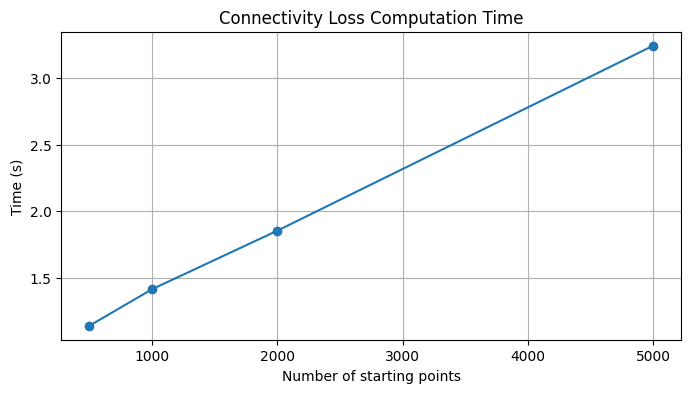

In [35]:
import time

# Benchmark
times = []
for n_samples in [500, 1000, 2000, 5000]:
    t0 = time.time()
    _ = connectivity_loss(model, bounds, n_samples=n_samples, n_iter=30)
    times.append((n_samples, time.time() - t0))
    print(f"n_samples={n_samples}: {times[-1][1]:.2f}s")

plt.figure(figsize=(8, 4))
plt.plot([t[0] for t in times], [t[1] for t in times], 'o-')
plt.xlabel('Number of starting points')
plt.ylabel('Time (s)')
plt.title('Connectivity Loss Computation Time')
plt.grid(True)
plt.show()

## 7. Next Steps

If this approach works:
1. **Integrate into training loop** — add to `train/losses_connectivity.py`
2. **Optimize** — reduce frequency, cache results
3. **Test on real shapes** — load pretrained model and verify saddles are meaningful

If too slow/unreliable:
1. **Alternative: Grid-based connectivity** — check connected components on discretized grid
2. **Alternative: Persistent homology** — use TDA libraries (GUDHI, giotto-tda)
3. **Alternative: Soft approximation** — penalize isolated minima instead of finding exact saddles

In [36]:
# Alternative: Simple grid-based connectivity check
from scipy import ndimage

def count_connected_components(model, bounds, resolution=64, level=0.0):
    """Count connected components of the level set using discrete grid."""
    x = torch.linspace(bounds[0, 0], bounds[0, 1], resolution, device=device)
    y = torch.linspace(bounds[1, 0], bounds[1, 1], resolution, device=device)
    z = torch.linspace(bounds[2, 0], bounds[2, 1], resolution, device=device)
    
    X, Y, Z = torch.meshgrid(x, y, z, indexing='ij')
    pts = torch.stack([X.flatten(), Y.flatten(), Z.flatten()], dim=1)
    
    with torch.no_grad():
        values = model(pts).squeeze().reshape(resolution, resolution, resolution)
    
    # Binary mask of interior
    interior = (values < level).cpu().numpy()
    
    # Count connected components
    labeled, n_components = ndimage.label(interior)
    
    return n_components, labeled

n_components, _ = count_connected_components(model, bounds)
print(f"Number of connected components: {n_components}")

Number of connected components: 6


In [37]:
# Simple connectivity loss based on component count
# NOTE: This is not differentiable! Would need soft relaxation.

def simple_connectivity_metric(model, bounds, resolution=64, level=0.0):
    """Non-differentiable connectivity metric for evaluation."""
    n_components, _ = count_connected_components(model, bounds, resolution, level)
    return n_components

print(f"Simple connectivity check: {simple_connectivity_metric(model, bounds)} components")

Simple connectivity check: 6 components


## Test Phase 2: Diversity Loss

Let's verify the diversity loss implementation works correctly by:
1. Generating surface points for multiple shapes (different z values)
2. Computing pairwise Chamfer distances
3. Checking the diversity loss gradient flows

In [38]:
# Test diversity loss imports
import sys
sys.path.insert(0, '..')

from train.losses_diversity import (
    pairwise_chamfer_distance,
    symmetric_chamfer_distance,
    diversity_loss_chamfer,
    diversity_loss_contrastive,
    diversity_loss_volume_symmetric_difference,
)
from models.point_wrapper import PointWrapper

print("✓ Diversity loss imports successful!")

✓ Diversity loss imports successful!


In [43]:
# Generate surface points for multiple shapes with different z values
n_shapes = 4
n_points_per_shape = 500
z_values = torch.linspace(-0.5, 0.5, n_shapes).unsqueeze(1).repeat(1, config['model']['nz']).to(device)

print(f"Testing with {n_shapes} shapes, z values ranging from -0.5 to 0.5")

# Extract surface points for each shape using marching cubes
from skimage import measure

surface_pts_list = []
resolution = 64

for i, z_i in enumerate(z_values):
    # Create a wrapper model for this z
    class ShapeModel:
        def __init__(self, model_raw, z):
            self.model_raw = model_raw
            self.z = z.unsqueeze(0)  # [1, nz]
        def __call__(self, x):
            return self.model_raw(x, self.z.expand(x.shape[0], -1))
    
    shape_model = ShapeModel(model_raw, z_i)
    
    # Sample on grid
    xs = torch.linspace(bounds[0, 0], bounds[0, 1], resolution, device=device)
    ys = torch.linspace(bounds[1, 0], bounds[1, 1], resolution, device=device)
    zs = torch.linspace(bounds[2, 0], bounds[2, 1], resolution, device=device)
    grid_pts = torch.stack(torch.meshgrid(xs, ys, zs, indexing='ij'), dim=-1).reshape(-1, 3)
    
    with torch.no_grad():
        sdf_vals = shape_model(grid_pts).squeeze()
    sdf_grid = sdf_vals.reshape(resolution, resolution, resolution).cpu().numpy()
    
    # Extract surface via marching cubes
    try:
        verts_i, faces_i, _, _ = measure.marching_cubes(sdf_grid, level=0.0)
        # Normalize to bounds
        verts_i = verts_i / (resolution - 1)
        verts_i = verts_i * (bounds[:, 1] - bounds[:, 0]).cpu().numpy() + bounds[:, 0].cpu().numpy()
        verts_tensor = torch.tensor(verts_i, dtype=torch.float32, device=device)
        
        # Subsample if too many
        if len(verts_tensor) > n_points_per_shape:
            idx = torch.randperm(len(verts_tensor))[:n_points_per_shape]
            verts_tensor = verts_tensor[idx]
        
        surface_pts_list.append(verts_tensor)
        print(f"  Shape {i}: z={z_i[0]:.2f}, {len(verts_tensor)} surface points")
    except:
        print(f"  Shape {i}: Failed to extract surface (may be empty)")
        surface_pts_list.append(torch.zeros(10, 3, device=device))

print(f"\n✓ Generated surface points for {n_shapes} shapes")

Testing with 4 shapes, z values ranging from -0.5 to 0.5
  Shape 0: z=-0.50, 500 surface points
  Shape 1: z=-0.17, 500 surface points
  Shape 2: z=0.17, 500 surface points
  Shape 3: z=0.50, 227 surface points

✓ Generated surface points for 4 shapes


In [40]:
# Test pairwise Chamfer distance
print("Testing pairwise Chamfer distances:\n")

# Compute pairwise distances manually
for i in range(n_shapes):
    for j in range(i+1, n_shapes):
        cd = symmetric_chamfer_distance(surface_pts_list[i], surface_pts_list[j])
        print(f"  CD(shape_{i}, shape_{j}) = {cd.item():.4f}")

print("\n" + "="*50)

# Test the full diversity loss using PointWrapper
pw = PointWrapper.create_from_pts_per_shape_list(surface_pts_list)
print(f"\nPointWrapper created: {pw.bz} shapes, {len(pw.data)} total points")

# Compute diversity loss
div_loss_min = diversity_loss_chamfer(pw, aggregation='min')
div_loss_mean = diversity_loss_chamfer(pw, aggregation='mean')

print(f"\nDiversity loss (aggregation='min'):  {div_loss_min.item():.4f}")
print(f"Diversity loss (aggregation='mean'): {div_loss_mean.item():.4f}")
print(f"\nNote: Negative values mean high diversity (loss to minimize)")
print(f"      More negative = more diverse shapes = good!")

Testing pairwise Chamfer distances:

  CD(shape_0, shape_1) = 0.6301
  CD(shape_0, shape_2) = 0.6734
  CD(shape_0, shape_3) = 0.9277
  CD(shape_1, shape_2) = 0.6971
  CD(shape_1, shape_3) = 0.6170
  CD(shape_2, shape_3) = 0.6481


PointWrapper created: 4 shapes, 1727 total points

Diversity loss (aggregation='min'):  -0.6170
Diversity loss (aggregation='mean'): -0.6280

Note: Negative values mean high diversity (loss to minimize)
      More negative = more diverse shapes = good!


In [41]:
# Test contrastive diversity loss
print("Testing contrastive diversity loss:\n")

# Create fake shape features (using mean of surface points as simple feature)
shape_features = torch.stack([pts.mean(dim=0) for pts in surface_pts_list])
print(f"Shape features: {shape_features.shape}")  # [n_shapes, 3]

# Expand to more features for meaningful contrastive loss
# Use point statistics: mean, std, min, max
shape_features_expanded = torch.cat([
    torch.stack([pts.mean(dim=0) for pts in surface_pts_list]),
    torch.stack([pts.std(dim=0) for pts in surface_pts_list]),
    torch.stack([pts.min(dim=0).values for pts in surface_pts_list]),
    torch.stack([pts.max(dim=0).values for pts in surface_pts_list]),
], dim=1)
print(f"Expanded features: {shape_features_expanded.shape}")  # [n_shapes, 12]

contrastive_loss = diversity_loss_contrastive(
    z_batch=z_values,
    f_batch=shape_features_expanded,
    temperature=0.1
)
print(f"\nContrastive diversity loss: {contrastive_loss.item():.4f}")
print("(Penalizes when different z produce similar shapes)")

Testing contrastive diversity loss:

Shape features: torch.Size([4, 3])
Expanded features: torch.Size([4, 12])

Contrastive diversity loss: 3.7718
(Penalizes when different z produce similar shapes)


In [42]:
# Visualize the different shapes to see diversity
import k3d
import numpy as np

plot = k3d.plot(name='Shape Diversity Test')
colors = [0xFF0000, 0x00FF00, 0x0000FF, 0xFFFF00]  # Red, Green, Blue, Yellow

for i, pts in enumerate(surface_pts_list):
    pts_np = pts.cpu().numpy().astype(np.float32)
    plot += k3d.points(pts_np, color=colors[i % len(colors)], 
                       point_size=0.02, name=f'Shape {i} (z={z_values[i, 0].item():.2f})')

plot.display()
print("\nVisualization: Each color = different shape (different z value)")
print("If shapes look different → high diversity → negative loss ✓")

Output()


Visualization: Each color = different shape (different z value)
If shapes look different → high diversity → negative loss ✓


## Test Phase 3: Connectivity Loss Module

Now let's verify the connectivity loss module (`train/losses_connectivity.py`) works correctly:

In [44]:
# Test connectivity loss imports from the new module
from train.losses_connectivity import (
    find_critical_points_newton,
    classify_critical_points,
    connectivity_loss_saddle,
    connectivity_loss_component_count,
    CachedConnectivityLoss,
    soft_connectivity_loss,
)

print("✓ Connectivity loss imports successful!")

✓ Connectivity loss imports successful!


In [45]:
# Test the module's find_critical_points_newton function
# This should match our prototype implementation

print("Testing find_critical_points_newton from module...")
t0 = time.time()

critical_pts_module, grad_norms_module, f_values_module = find_critical_points_newton(
    f=model,  # Our FixedLatentModel wrapper
    bounds=bounds,
    n_starting_points=2000,
    n_iter=50,
    grad_tol=1e-2,
    verbose=True
)

print(f"\nTime: {time.time() - t0:.2f}s")
print(f"Found {len(critical_pts_module)} critical points")
if len(critical_pts_module) > 0:
    print(f"f-value range: [{f_values_module.min():.4f}, {f_values_module.max():.4f}]")

Testing find_critical_points_newton from module...


|∇f| mean=1.97e-01, min=3.88e-04: 100%|██████████| 50/50 [00:03<00:00, 15.02it/s]


Time: 3.35s
Found 711 critical points
f-value range: [-0.0242, 0.3626]


In [46]:
# Test the full connectivity_loss_saddle function
print("Testing connectivity_loss_saddle...")
t0 = time.time()

loss_saddle, info = connectivity_loss_saddle(
    f=model,
    bounds=bounds,
    n_samples=1000,
    n_iter=30,
    grad_tol=1e-2,
    verbose=True
)

print(f"\nTime: {time.time() - t0:.2f}s")
print(f"Connectivity loss: {loss_saddle.item():.6f}")
print(f"Info: {info}")

Testing connectivity_loss_saddle...


|∇f| mean=2.68e-01, min=2.73e-03: 100%|██████████| 30/30 [00:01<00:00, 20.76it/s]


Time: 1.47s
Connectivity loss: 0.009574
Info: {'n_critical_pts': 22, 'n_saddles': 11, 'saddle_f_values': tensor([0.1357, 0.0157, 0.0291, 0.1029, 0.1444, 0.1150, 0.1190, 0.0937, 0.0304,
        0.0933, 0.0927])}


In [47]:
# Test the CachedConnectivityLoss for efficiency
print("Testing CachedConnectivityLoss...")

cached_loss = CachedConnectivityLoss(
    bounds=bounds,
    n_samples=1000,
    n_iter=30,
    grad_tol=1e-2,
    update_every_n_epochs=10,  # Update cache every 10 epochs
)

# Simulate multiple epochs
for epoch in [0, 5, 10, 15]:
    t0 = time.time()
    loss, info = cached_loss(model, epoch)
    elapsed = time.time() - t0
    cache_status = "UPDATED" if info.get('cache_updated', False) else "cached"
    print(f"Epoch {epoch:2d}: loss={loss.item():.6f}, time={elapsed:.2f}s ({cache_status})")

print("\n✓ CachedConnectivityLoss working - notice epoch 0 and 10 take longer (cache update)")

Testing CachedConnectivityLoss...
Epoch  0: loss=0.006505, time=2.76s (UPDATED)
Epoch  5: loss=0.006989, time=0.00s (cached)
Epoch 10: loss=0.010698, time=2.68s (UPDATED)
Epoch 15: loss=0.009032, time=0.00s (cached)

✓ CachedConnectivityLoss working - notice epoch 0 and 10 take longer (cache update)


In [48]:
# Compare with discrete component count (ground truth)
print("Comparing Morse theory with discrete component count...")

# Discrete method
metric, n_components_discrete = connectivity_loss_component_count(model, bounds, resolution=64)
print(f"Discrete connected components: {n_components_discrete}")

# Morse theory saddle count
if len(critical_pts_module) > 0:
    morse_idx, _ = classify_critical_points(model, critical_pts_module)
    n_saddles_1 = (morse_idx == 1).sum().item()
    print(f"Index-1 saddles found: {n_saddles_1}")
    print(f"(Saddles with f≠0 indicate potential disconnection)")

print(f"\nConnectivity loss value: {loss_saddle.item():.6f}")
print("If loss > 0: saddles have f≠0 → disconnected components likely")
print("If loss ≈ 0: saddles on surface → likely connected")

Comparing Morse theory with discrete component count...
Discrete connected components: 6
Index-1 saddles found: 267
(Saddles with f≠0 indicate potential disconnection)

Connectivity loss value: 0.009574
If loss > 0: saddles have f≠0 → disconnected components likely
If loss ≈ 0: saddles on surface → likely connected
